<a href="https://colab.research.google.com/github/DienAkbar25/DesainAnalisisAlgoritma/blob/Angel/DAA(Kahn_VS_DFS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
from itertools import combinations
import sys
sys.setrecursionlimit(1_000_000)
import time, gc, statistics, random


In [57]:
MASTER_SEED = 12345
random.seed(MASTER_SEED)
print(f"[SEED LOG] MASTER_SEED = {MASTER_SEED}")

[SEED LOG] MASTER_SEED = 12345


In [58]:
places = {
    1: "Malioboro",
    2: "Tugu Jogja",
    3: "Alun-Alun Kidul",
    4: "Keraton Yogyakarta",
    5: "Taman Sari",
    6: "Museum Sonobudoyo",
    7: "Candi Prambanan",
    8: "Ratu Boko",
    9: "Tebing Breksi",
    10: "Kaliurang",
    11: "Basecamp Lava Tour Merapi",
    12: "Museum Ullen Sentalu",
    13: "Pantai Parang Teritis",
    14: "HeHa Sky View",
    15: "Hutan Pinus Pengger",
}

In [59]:
day = {
    1: 1, 2: 1, 3: 1,
    4: 2, 5: 2, 6: 2,
    7: 3, 8: 3, 9: 3,
    10: 4, 11: 4, 12: 4,
    13: 5, 14: 5, 15: 5
}

N = len(places)

In [60]:
order_by_day = {d: sorted([n for n,t in day.items() if t==d]) for d in sorted(set(day.values()))}

linear_graph = {n: [] for n in places.keys()}
days_sorted = sorted(order_by_day.keys())
for i, d in enumerate(days_sorted):
    seq = order_by_day[d]
    # chain inside day
    for j in range(len(seq)-1):
        linear_graph[seq[j]].append((seq[j+1], 1))
    # connect last of day to first of next day
    if i < len(days_sorted)-1:
        linear_graph[seq[-1]].append((order_by_day[days_sorted[i+1]][0], 1))

print("Linear adjacency list (debug):")
for u in sorted(linear_graph.keys()):
    print(f"{u:2d} -> {linear_graph[u]}")
print()

Linear adjacency list (debug):
 1 -> [(2, 1)]
 2 -> [(3, 1)]
 3 -> [(4, 1)]
 4 -> [(5, 1)]
 5 -> [(6, 1)]
 6 -> [(7, 1)]
 7 -> [(8, 1)]
 8 -> [(9, 1)]
 9 -> [(10, 1)]
10 -> [(11, 1)]
11 -> [(12, 1)]
12 -> [(13, 1)]
13 -> [(14, 1)]
14 -> [(15, 1)]
15 -> []



In [61]:
def topo_kahn(adj):
    indeg = {n:0 for n in adj}
    for u, edges in adj.items():
        for v,w in edges:
            indeg[v] += 1
    dq = deque([n for n in sorted(indeg.keys()) if indeg[n] == 0])
    out = []
    while dq:
        u = dq.popleft()
        out.append(u)
        for v,w in adj[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                dq.append(v)
    return out


In [62]:
def topo_dfs(adj, day_map=None):
    visited = {n: False for n in adj}
    stack = []
    def dfs(u):
        visited[u] = True
        for v, w in sorted(adj.get(u, []), key=lambda x: x[0]):
            if not visited[v]:
                dfs(v)
        stack.append(u)
    if day_map is not None:
        start_nodes = sorted(adj.keys(), key=lambda x: (day_map.get(x, 0), x))
    else:
        start_nodes = sorted(adj.keys())
    for n in start_nodes:
        if not visited[n]:
            dfs(n)

    stack.reverse()
    return stack

In [63]:
def time_func(func, *args, reps=30):
    t0 = time.perf_counter()
    for _ in range(reps):
        func(*args)
    t1 = time.perf_counter()
    return (t1 - t0) / reps * 1000.0  # ms

order_kahn = topo_kahn(linear_graph)
order_dfs  = topo_dfs(linear_graph, day)

time_kahn = time_func(topo_kahn, linear_graph, reps=50)
time_dfs  = time_func(topo_dfs, linear_graph, day, reps=50)


In [64]:
def kendall_stability(a, b):
    assert set(a) == set(b)
    pos_b = {v:i for i,v in enumerate(b)}
    n = len(a)
    discord = 0
    total = 0
    for i,j in combinations(range(n), 2):
        u = a[i]; v = a[j]
        if pos_b[u] > pos_b[v]:
            discord += 1
        total += 1
    return 1.0 - (discord / total)

stability = kendall_stability(order_kahn, order_dfs)


In [65]:
def pos_per_day(order_by_day, x_step=3.0, y_step=2.0):
    pos = {}
    maxlen = max(len(v) for v in order_by_day.values())
    for i, d in enumerate(sorted(order_by_day.keys())):
        seq = order_by_day[d]
        x = i * x_step
        mid = (maxlen - 1) / 2
        for j, node in enumerate(seq):
            y = (mid - j) * y_step
            pos[node] = (x, y)
    return pos

def pos_from_order(order, x_step=1.5, y_level=0):
    pos = {}
    for i, node in enumerate(order):
        pos[node] = (i * x_step, y_level)
    return pos

def pos_day_topo(order, day_map, x_step=3.0, y_step=0.7):
    pos = {}
    rank = {n:i for i,n in enumerate(order)}
    for node in order:
        d = day_map[node]
        x = (d-1) * x_step
        y = -rank[node] * y_step
        pos[node] = (x, y)
    return pos

# build positions
pos_day = pos_per_day(order_by_day)
pos_kahn_topo = pos_from_order(order_kahn, x_step=1.2)
pos_dfs_topo  = pos_from_order(order_dfs, x_step=1.2)
pos_day_kahn_topo = pos_day_topo(order_kahn, day)
pos_day_dfs_topo = pos_day_topo(order_dfs, day)

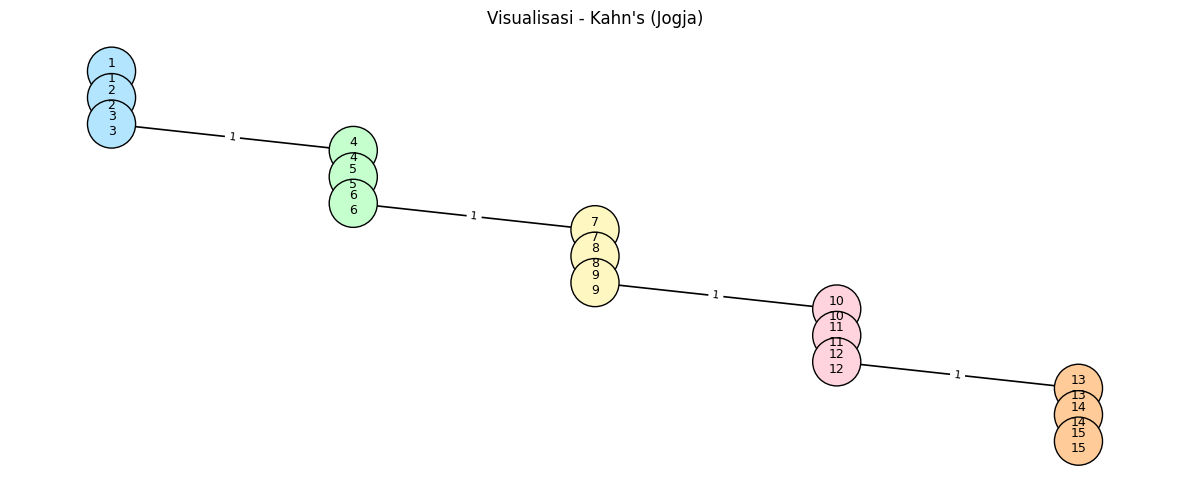

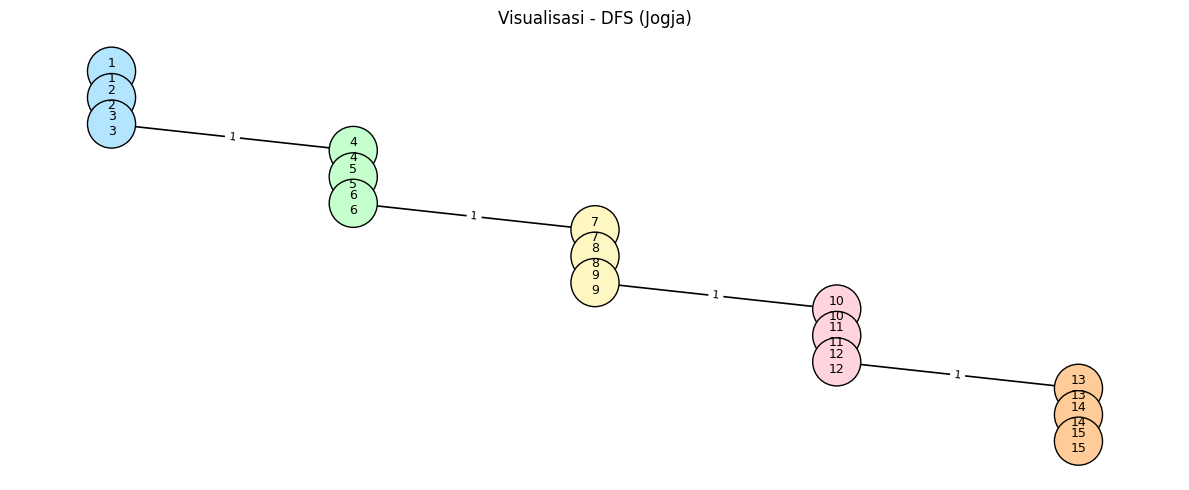

In [66]:
colors = {
    1:"#b3e5ff",
    2:"#c4ffcd",
    3:"#fff7c2",
    4:"#ffd4de",
    5:"#ffcc99"
}

def draw_graph(adj, pos, order=None, title=""):
    G = nx.DiGraph()
    for u, edges in adj.items():
        for v,w in edges:
            G.add_edge(u, v, weight=w)

    nodelist = sorted(G.nodes())
    edgelist = sorted(G.edges())

    # kalau day map ada (graf jogja), warna pakai day, kalau tidak ada -> abu
    def node_color(n):
        return colors.get(day.get(n, 1), "#dddddd")

    node_colors = [node_color(n) for n in nodelist]

    plt.figure(figsize=(12,5))
    nx.draw_networkx_nodes(G, pos, nodelist=nodelist, node_size=1200,
                           node_color=node_colors, edgecolors='k')
    nx.draw_networkx_edges(G, pos, edgelist=edgelist, arrowstyle='-|>', arrowsize=14, width=1.2)

    edge_labels = {(u,v): G[u][v]['weight'] for u,v in edgelist}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    if order is not None:
        rank = {n:i+1 for i,n in enumerate(order)}
        labels = {n: f"{rank[n]}\n{str(n)}" for n in nodelist}
    else:
        labels = {n: str(n) for n in nodelist}

    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_graph(linear_graph, pos_day_kahn_topo, order=order_kahn, title="Visualisasi - Kahn's (Jogja)")
draw_graph(linear_graph, pos_day_dfs_topo,  order=order_dfs,  title="Visualisasi - DFS (Jogja)")


In [67]:
def bench(func, *args, reps=200):
    """Return list of runtimes in ms for `reps` runs (single-call timings)."""
    times = []
    for _ in range(20):
        func(*args)
    gc_old = gc.isenabled()
    gc.disable()
    try:
        for _ in range(reps):
            t0 = time.perf_counter()
            func(*args)
            t1 = time.perf_counter()
            times.append((t1-t0)*1000.0)
    finally:
        if gc_old:
            gc.enable()
    return times

reps = 500
times_kahn = bench(topo_kahn, linear_graph, reps=reps)
times_dfs  = bench(topo_dfs,  linear_graph, day, reps=reps)

def summarize(times):
    return {
        'n': len(times),
        'mean_ms': statistics.mean(times),
        'median_ms': statistics.median(times),
        'stdev_ms': statistics.stdev(times) if len(times)>1 else 0.0,
        'min_ms': min(times),
        'max_ms': max(times)
    }

print("\n=== STEP-BY-STEP KOMPLEKSITAS (sesuai kode) ===")
print("Kahn:")
print("  - Hitung indegree: scan semua edge -> O(E)")
print("  - Queue init + sorting node: O(V log V)")
print("  - While queue: pop tiap node sekali -> O(V), scan tiap edge sekali -> O(E)")
print("  => Total: O(V log V + E)")
print("DFS:")
print("  - Sorting start_nodes: O(V log V)")
print("  - DFS visit tiap node sekali -> O(V), scan tiap edge sekali -> O(E)")
print("  => Total: O(V log V + E) (karena kita sort start_nodes & neighbor)\n")

print("Batas bawah (optimal): graf linear (E=V-1) ~ O(V log V)")
print("Batas atas (non-optimal): graf lebih padat (E besar) ~ O(V log V + E)\n")


=== STEP-BY-STEP KOMPLEKSITAS (sesuai kode) ===
Kahn:
  - Hitung indegree: scan semua edge -> O(E)
  - Queue init + sorting node: O(V log V)
  - While queue: pop tiap node sekali -> O(V), scan tiap edge sekali -> O(E)
  => Total: O(V log V + E)
DFS:
  - Sorting start_nodes: O(V log V)
  - DFS visit tiap node sekali -> O(V), scan tiap edge sekali -> O(E)
  => Total: O(V log V + E) (karena kita sort start_nodes & neighbor)

Batas bawah (optimal): graf linear (E=V-1) ~ O(V log V)
Batas atas (non-optimal): graf lebih padat (E besar) ~ O(V log V + E)



In [68]:
# --------- generator graf sederhana (tanpa mengubah fungsi topo kamu) ----------
def make_linear_dag(n):
    adj = {i: [] for i in range(1, n+1)}
    for i in range(1, n):
        adj[i].append((i+1, 1))
    return adj

def make_random_dag(n, density=0.02, seed=0):
    rng = random.Random(seed)
    adj = {i: [] for i in range(1, n+1)}
    for i in range(1, n):
        for j in range(i+1, n+1):
            if rng.random() < density:
                adj[i].append((j, 1))
        adj[i].sort(key=lambda x: x[0])
    return adj

def count_edges(adj):
    return sum(len(e) for e in adj.values())


In [69]:
def dfs_stepcount(adj):
    visited = {n: False for n in adj}
    scan_edge = 0
    dfs_call = 0
    start_check = 0
    stack_out = []

    # start nodes deterministik
    for start in sorted(adj.keys()):
        start_check += 1
        if visited[start]:
            continue

        # stack untuk simulasi rekursi: (node, next_index)
        stack = [(start, 0)]
        visited[start] = True
        dfs_call += 1

        while stack:
            u, i = stack[-1]
            neigh = adj.get(u, [])

            if i < len(neigh):
                v, w = neigh[i]
                scan_edge += 1
                stack[-1] = (u, i + 1)

                if not visited[v]:
                    visited[v] = True
                    dfs_call += 1
                    stack.append((v, 0))
            else:
                # selesai jelajah u
                stack_out.append(u)
                stack.pop()

    # reverse untuk topo order, tapi buat step count doang nggak wajib
    steps = start_check + dfs_call + scan_edge
    return steps


In [70]:
def paired_t_test(x, y):
    assert len(x) == len(y) and len(x) >= 2
    d = [xi - yi for xi, yi in zip(x, y)]
    n = len(d)
    mean_d = statistics.mean(d)
    sd_d = statistics.stdev(d)

    df = n - 1

    # KASUS KHUSUS: tidak ada variasi selisih (sd=0)
    # - kalau mean_d juga 0: dua metode identik -> t=0, p=1
    # - kalau mean_d != 0: selisih konstan -> "t tak terhingga", p ~ 0
    if sd_d == 0:
        if mean_d == 0:
            return 0.0, df, 1.0
        else:
            # beda konstan tanpa variasi
            return float("inf"), df, 0.0

    t = mean_d / (sd_d / math.sqrt(n))

    # normal approx (two-sided)
    p = 2.0 * (1.0 - 0.5 * (1.0 + math.erf(abs(t) / math.sqrt(2))))
    return t, df, p



=== n=10 ===
OPTIMAL (linear): E=9, mean_steps(Kahn)=37.00, mean_steps(DFS)=29.00, p=0
NON-OPT (random): E~1, mean_steps(Kahn)=13.05, mean_steps(DFS)=21.05, p=0


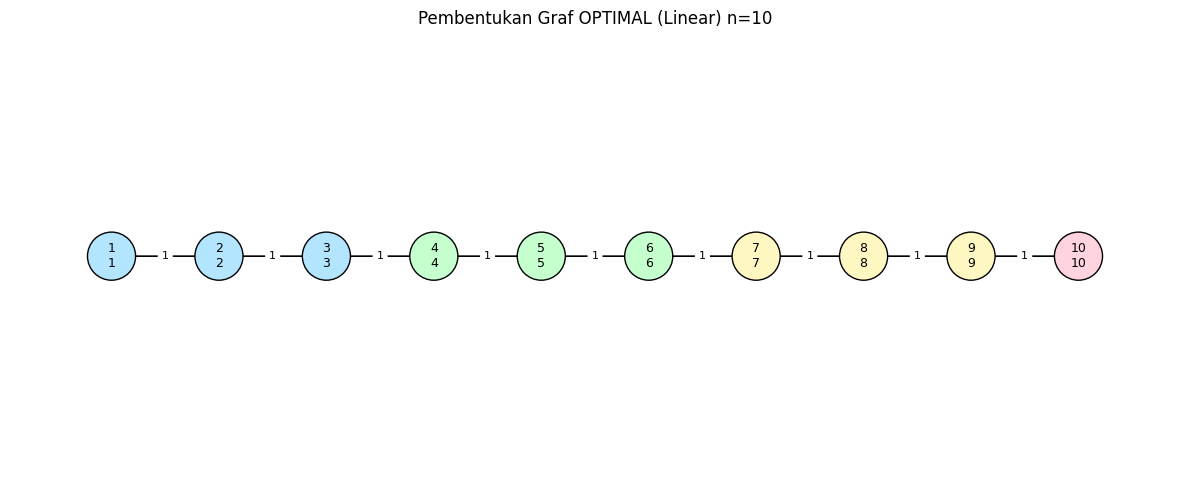

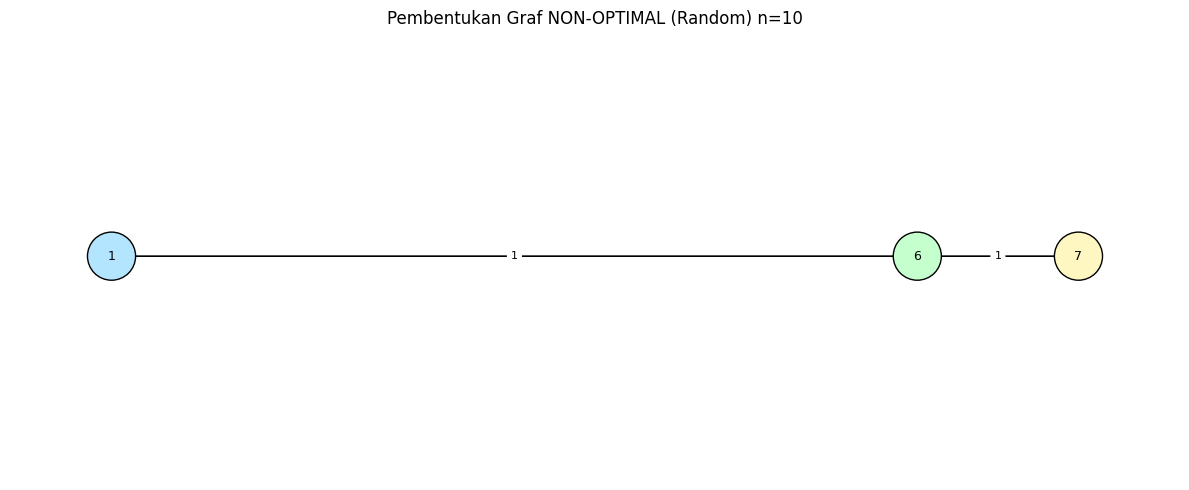


=== n=20 ===
OPTIMAL (linear): E=19, mean_steps(Kahn)=77.00, mean_steps(DFS)=59.00, p=0
NON-OPT (random): E~3, mean_steps(Kahn)=30.50, mean_steps(DFS)=43.70, p=0


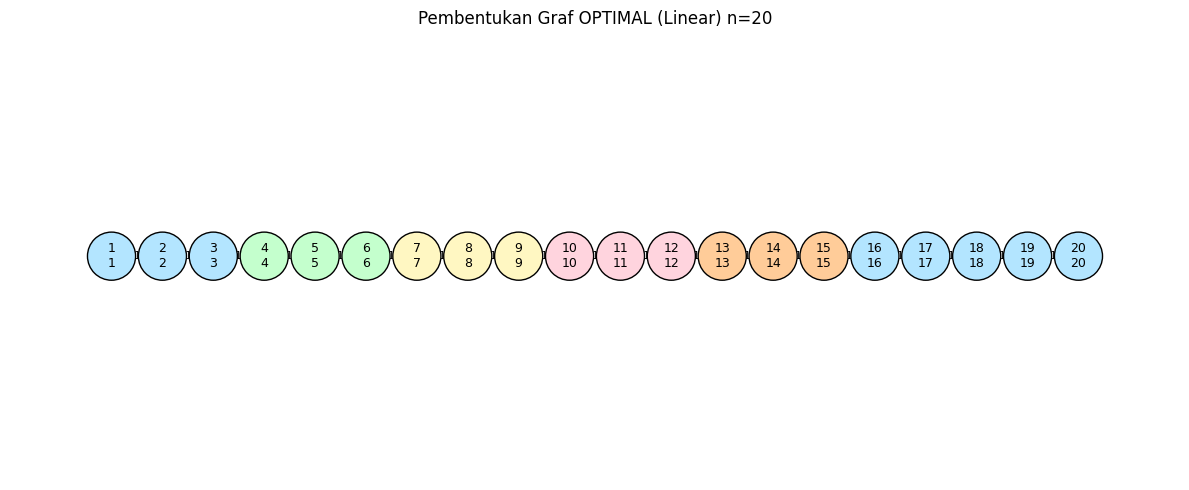

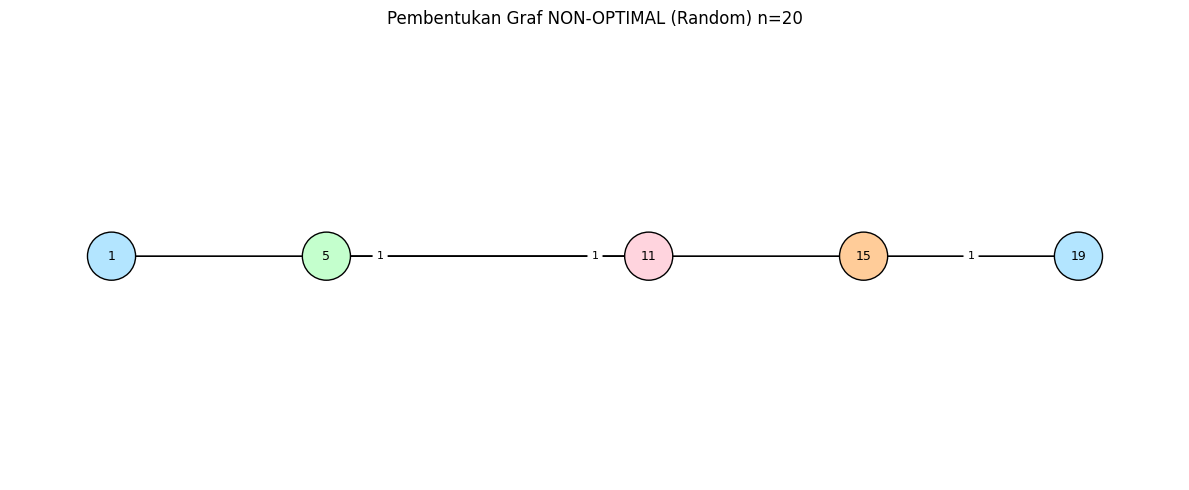


=== n=50 ===
OPTIMAL (linear): E=49, mean_steps(Kahn)=197.00, mean_steps(DFS)=149.00, p=0
NON-OPT (random): E~24, mean_steps(Kahn)=117.70, mean_steps(DFS)=124.75, p=2.012e-07

=== n=1000 ===
OPTIMAL (linear): E=999, mean_steps(Kahn)=3997.00, mean_steps(DFS)=2999.00, p=0
NON-OPT (random): E~9988, mean_steps(Kahn)=21926.30, mean_steps(DFS)=11988.65, p=0


In [71]:
# --------- eksperimen n = 10/20/50/1000 ----------
SIZES = [10, 20, 50, 1000]
REPS = 20            # banyak graf untuk uji statistik (paired t-test)
DENSITY = 0.02

summary_rows = []  # simpan untuk plot mean steps

for n in SIZES:
    # OPTIMAL: linear DAG (selalu sama)
    adj_opt = make_linear_dag(n)
    E_opt = count_edges(adj_opt)

    # NON-OPTIMAL: random DAG (seed terkunci -> reproducible)
    # kita buat banyak graf (REPS) untuk t-test
    opt_kahn = []
    opt_dfs = []
    non_kahn = []
    non_dfs = []
    E_non_list = []

    for r in range(REPS):
        # graf optimal sama terus (boleh tetap dihitung berkali2)
        opt_kahn.append(kahn_stepcount(adj_opt))
        opt_dfs.append(dfs_stepcount(adj_opt))

        seed_r = MASTER_SEED * 100000 + n * 100 + r
        adj_non = make_random_dag(n, density=DENSITY, seed=seed_r)
        E_non_list.append(count_edges(adj_non))

        non_kahn.append(kahn_stepcount(adj_non))
        non_dfs.append(dfs_stepcount(adj_non))

    # uji statistik
    t_opt, df_opt, p_opt = paired_t_test(opt_kahn, opt_dfs)
    t_non, df_non, p_non = paired_t_test(non_kahn, non_dfs)

    print(f"\n=== n={n} ===")
    print(f"OPTIMAL (linear): E={E_opt}, mean_steps(Kahn)={statistics.mean(opt_kahn):.2f}, mean_steps(DFS)={statistics.mean(opt_dfs):.2f}, p={p_opt:.4g}")
    print(f"NON-OPT (random): E~{int(statistics.mean(E_non_list))}, mean_steps(Kahn)={statistics.mean(non_kahn):.2f}, mean_steps(DFS)={statistics.mean(non_dfs):.2f}, p={p_non:.4g}")

    summary_rows.append((n, statistics.mean(opt_kahn), statistics.mean(opt_dfs),
                         statistics.mean(non_kahn), statistics.mean(non_dfs)))

    # tampilkan pembentukan graf (hanya untuk n kecil biar ga berat)
    if n in (10, 20):
        # pos sederhana satu garis
        pos_line = {i: (i, 0) for i in range(1, n+1)}
        draw_graph(adj_opt, pos_line, order=list(range(1, n+1)), title=f"Pembentukan Graf OPTIMAL (Linear) n={n}")
        # contoh 1 graf random pertama
        adj_non_example = make_random_dag(n, density=DENSITY, seed=MASTER_SEED * 100000 + n * 100 + 0)
        draw_graph(adj_non_example, pos_line, order=None, title=f"Pembentukan Graf NON-OPTIMAL (Random) n={n}")

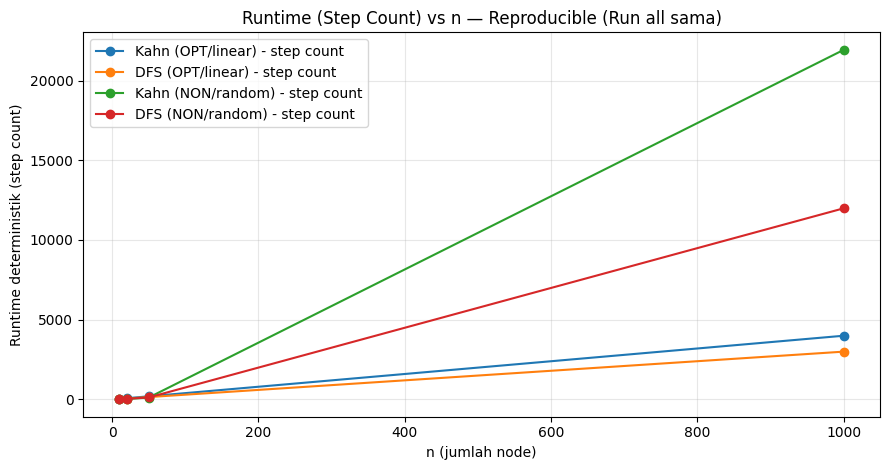


[INFO] Wall-clock runtime (ms) pake perf_counter itu wajar berubah tiap Run all.
       Di laporan, kamu pakai step count untuk reproducibility.

[DEMO perf_counter] n=50, E=26 | Kahn~0.015346 ms | DFS~0.022911 ms

=== JOGJA GRAPH RESULT (original) ===
Order Kahn: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Order DFS : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Stability : 1.0000
Runtime ms Kahn (perf_counter avg): 0.005465 ms
Runtime ms DFS  (perf_counter avg): 0.013075 ms


In [72]:
# --------- grafik runtime (reproducible) ----------
ns = [r[0] for r in summary_rows]
opt_k = [r[1] for r in summary_rows]
opt_d = [r[2] for r in summary_rows]
non_k = [r[3] for r in summary_rows]
non_d = [r[4] for r in summary_rows]

plt.figure(figsize=(9,4.8))
plt.plot(ns, opt_k, marker="o", label="Kahn (OPT/linear) - step count")
plt.plot(ns, opt_d, marker="o", label="DFS (OPT/linear) - step count")
plt.plot(ns, non_k, marker="o", label="Kahn (NON/random) - step count")
plt.plot(ns, non_d, marker="o", label="DFS (NON/random) - step count")
plt.xlabel("n (jumlah node)")
plt.ylabel("Runtime deterministik (step count)")
plt.title("Runtime (Step Count) vs n — Reproducible (Run all sama)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --------- (opsional) runtime ms pake perf_counter (ini wajar berubah) ----------
print("\n[INFO] Wall-clock runtime (ms) pake perf_counter itu wajar berubah tiap Run all.")
print("       Di laporan, kamu pakai step count untuk reproducibility.\n")

# contoh demo perf_counter untuk 1 ukuran saja
demo_n = 50
demo_adj = make_random_dag(demo_n, density=DENSITY, seed=MASTER_SEED + 999)
demo_kahn_ms = time_func(topo_kahn, demo_adj, reps=50)
demo_dfs_ms  = time_func(topo_dfs,  demo_adj, None, reps=50)
print(f"[DEMO perf_counter] n={demo_n}, E={count_edges(demo_adj)} | Kahn~{demo_kahn_ms:.6f} ms | DFS~{demo_dfs_ms:.6f} ms")

# =========================
# OUTPUT JOGJA (tetap)
# =========================
print("\n=== JOGJA GRAPH RESULT (original) ===")
print("Order Kahn:", order_kahn)
print("Order DFS :", order_dfs)
print(f"Stability : {stability:.4f}")
print(f"Runtime ms Kahn (perf_counter avg): {time_kahn:.6f} ms")
print(f"Runtime ms DFS  (perf_counter avg): {time_dfs:.6f} ms")